# Notebook 01: Exploring a Single Trail

**Goal:** open 1 GPX file and understand what trail data actually looks like, before building any model.

By the end, a raw GPX file will have:
- a clean pandas DataFrame,
- an elevation profile chart,
- a simple map of the route,
- and the first numbers that hint at *difficulty*.

In [ ]:
# gpxpy   -> reads .gpx files

import glob
import gpxpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading the GPX file

A GPX file is structured as a nest of layers:

```
gpx
 └── track        (one recorded trail)
      └── segment  (a continuous chunk of recording)
           └── points  (lat, lon, elevation, time)  <- the actual data
```

I used `glob` to grab whatever `.gpx` file is sitting in the folder, so this notebook works no matter what the file is named.

In [2]:
# Find the first GPX file in our data folder
gpx_path = glob.glob('../data/raw/gpx/*.gpx')[0]
print('Loading:', gpx_path)

# Parse it
with open(gpx_path, 'r', encoding='utf-8') as f:
    gpx = gpxpy.parse(f)

# How many tracks / segments / points?
track = gpx.tracks[0]
segment = track.segments[0]
print('Trail name :', track.name)
print('Tracks     :', len(gpx.tracks))
print('Segments   :', len(track.segments))
print('Points     :', len(segment.points))

Loading: ../data/raw/gpx/dolomitas-anello-della-cima-dellalbero-gruppo-del-bosconero-.gpx
Trail name : DOLOMITAS: ANELLO DELLA CIMA DELL'ALBERO (GRUPPO DEL BOSCONE... - Wikiloc
Tracks     : 1
Segments   : 1
Points     : 362


## Turning the points into a DataFrame

Walk through every point and collect its latitude, longitude, and elevation into a list of dictionaries, then create a table.

In [3]:
rows = []
for point in segment.points:
    rows.append({
        'lat': point.latitude,
        'lon': point.longitude,
        'elevation_m': point.elevation,
    })

df = pd.DataFrame(rows)
df.head()

,lat,lon,elevation_m
0,46.277513,12.295260,792.221
1,46.276970,12.294610,795.741
2,46.276902,12.294402,799.205
3,46.276966,12.294212,803.509
4,46.277065,12.294162,804.943


## Quick EDA

Find: shape, info, summary stats.

In [4]:
print('Shape:', df.shape)
df.info()
df.describe()

Shape: (362, 3)
<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   lat          362 non-null    float64
 1   lon          362 non-null    float64
 2   elevation_m  362 non-null    float64
dtypes: float64(3)
memory usage: 8.6 KB


,lat,lon,elevation_m
count,362.000000,362.000000,362.000000
mean,46.288608,12.280399,1356.092740
std,0.009529,0.009873,310.822078
min,46.269882,12.259651,792.221000
25%,46.282182,12.271085,1125.913250
50%,46.288068,12.281477,1400.070500
75%,46.296787,12.288535,1601.123250
max,46.303501,12.296099,1847.109000


## Data quality note

My computed numbers differ slightly from Wikiloc's official figures:

| Metric | Mine | Wikiloc | Why |
|--------|------|---------|-----|
| Distance | 13.5 km | 14.3 km | The "simplified" track has fewer points, so bends get straightened → shorter |
| Elevation gain | 1,495 m | 1,333 m | Raw summing counts GPS noise as climbing; smoothing the elevation (3-point average) gives ~1,300 m, matching Wikiloc |

**Takeaway:** elevation gain is noise-sensitive, so I'll smooth it in my feature pipeline. A small, *consistent* distance undercount is harmless for the model since every trail is measured the same way.

## Finding how far along the trail each point is

Right now, I only know *where* each point is (lat/lon), not *how far* it is along the trail. To plot a proper elevation profile, I need distance.

The catch: latitude/longitude are angles on a sphere, so I can't just subtract them. Thus, I use the **haversine formula**, which gives the real ground distance (in metres) between two lat/lon points, accounting for the Earth's curvature.

I then take a running total (`cumsum`) to get how far each point sits along the trail.

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    """Ground distance in metres between two lat/lon points."""
    R = 6_371_000  # Earth's radius in metres
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Distance from each point to the previous one
df['step_m'] = haversine(df['lat'].shift(), df['lon'].shift(), df['lat'], df['lon'])
df['step_m'] = df['step_m'].fillna(0)            # first point has no previous -> 0
df['dist_km'] = df['step_m'].cumsum() / 1000     # running total, in km

df[['lat', 'lon', 'elevation_m', 'step_m', 'dist_km']].head()

,lat,lon,elevation_m,step_m,dist_km
0,46.277513,12.295260,792.221,0.000000,0.000000
1,46.276970,12.294610,795.741,78.365505,0.078366
2,46.276902,12.294402,799.205,17.683876,0.096049
3,46.276966,12.294212,803.509,16.244249,0.112294
4,46.277065,12.294162,804.943,11.659730,0.123953


## The elevation profile

This is the single most important picture of a trail. The x-axis is distance along the trail; the y-axis is height. Steep climbs, flat sections, and descents can be seen easily.

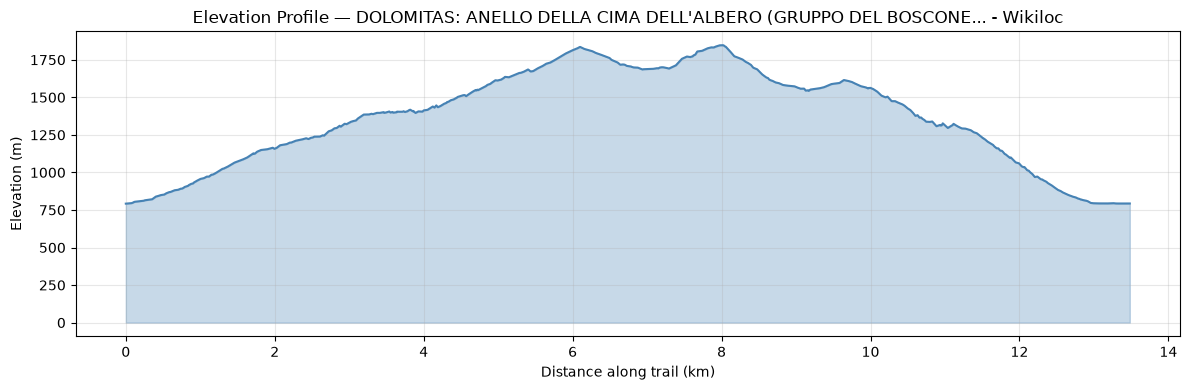

In [6]:
plt.figure(figsize=(12, 4))
plt.fill_between(df['dist_km'], df['elevation_m'], alpha=0.3, color='steelblue')
plt.plot(df['dist_km'], df['elevation_m'], color='steelblue', linewidth=1.5)
plt.xlabel('Distance along trail (km)')
plt.ylabel('Elevation (m)')
plt.title(f'Elevation Profile — {track.name}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## A simple map

Plotting longitude on the x-axis and latitude on the y-axis gives rise to points that trace out the shape of the trail from above. Colouring by elevation lets high ground stands out.

I'll make a real interactive map with the actual terrain underneath later, this is the quick version.

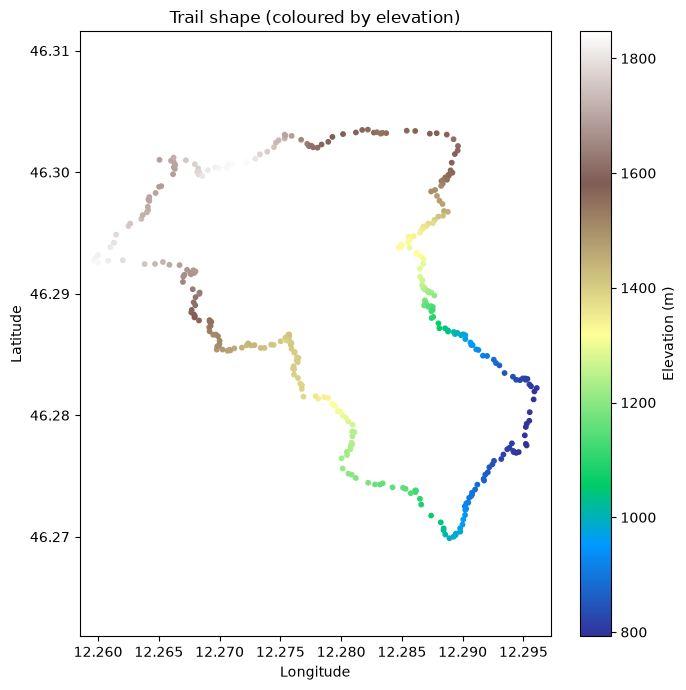

In [7]:
plt.figure(figsize=(7, 7))
sc = plt.scatter(df['lon'], df['lat'], c=df['elevation_m'], cmap='terrain', s=10)
plt.colorbar(sc, label='Elevation (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Trail shape (coloured by elevation)')
plt.axis('equal')   # keeps the shape from looking squashed
plt.tight_layout()
plt.show()

## First hints of difficulty

These are the kinds of numbers that *should* relate to how hard a trail is. They're the seeds of the features I'll engineer next.

**Elevation gain** = add up only the uphill bits (the climbing you actually do). This matters far more for difficulty than start-to-end height change, because a trail can go up and down many times.

In [8]:
df['elev_change'] = df['elevation_m'].diff().fillna(0)

total_distance_km = df['dist_km'].iloc[-1]
total_gain_m = df.loc[df['elev_change'] > 0, 'elev_change'].sum()
total_loss_m = -df.loc[df['elev_change'] < 0, 'elev_change'].sum()

print(f'Total distance     : {total_distance_km:.1f} km')
print(f'Total climbing (up): {total_gain_m:.0f} m')
print(f'Total descent      : {total_loss_m:.0f} m')
print(f'Highest point      : {df["elevation_m"].max():.0f} m')
print(f'Lowest point       : {df["elevation_m"].min():.0f} m')
print(f'Climb per km       : {total_gain_m/total_distance_km:.0f} m/km')

Total distance     : 13.5 km
Total climbing (up): 1495 m
Total descent      : 1494 m
Highest point      : 1847 m
Lowest point       : 792 m
Climb per km       : 111 m/km


## Recap & what's next

You just turned a raw GPX file into a table, two charts, and a set of difficulty-related numbers. That climb-per-km figure is exactly the kind of signal our model will learn from.

**Try it yourself** (optional, to build intuition):
- Change the `figsize` on a plot and re-run.
- Print `df.tail()` to see the end of the trail.
- Does the total climbing match what Wikiloc says for this trail? (It rated this one *Moderate*.)

**Next notebook:** we'll turn these one-off numbers into a reusable *feature function* and run it across many trails.